## 1. Instalação do Pyspark e importação de biblioteca

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_date, col
import matplotlib.pyplot as plt
import time
import os
import shutil
import math
import pandas as pd
import kagglehub

!pip install pyspark==3.5.0

In [ ]:
# Deleta pastas (se existir)
import os

folders = ['iceberg_warehouse', 'lifecycle']

for folder in folders:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"Deleted: {folder}")
    else:
        print(f"Folder not found: {folder}")

Folder not found: iceberg_warehouse
Folder not found: lifecycle


## 2. Configuração do Spark com Iceberg

In [ ]:
iceberg_version = "1.5.0"
scala_version = "2.12"

spark = SparkSession.builder \
    .appName("IcebergColab") \
    .config("spark.jars.packages", f"org.apache.iceberg:iceberg-spark-runtime-3.5_{scala_version}:{iceberg_version}") \
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
    .config("spark.sql.catalog.local", "org.apache.iceberg.spark.SparkCatalog") \
    .config("spark.sql.catalog.local.type", "hadoop") \
    .config("spark.sql.catalog.local.warehouse", "iceberg_warehouse") \
    .getOrCreate()

## 3. Criar view a partir do arquivo CSV com partições de 128 MB

In [ ]:
# Download dataset
path = kagglehub.dataset_download("aliafzal9323/chicago-crime-dataset-2024-2026")

print("Path to dataset:", path)

100%|██████████| 522M/522M [00:05<00:00, 105MB/s]

Extracting files...


Path to dataset: /root/.cache/kagglehub/datasets/aliafzal9323/chicago-crime-dataset-2024-2026/versions/1


In [ ]:
# Calcula numero de partições com base em 128MB cada
arquivo_path = path + "/chicago crimes.csv"
tamanho_alvo_mb = 128

tamanho_bytes = os.path.getsize(arquivo_path)
tamanho_mb = tamanho_bytes / (1024 * 1024)

num_particoes = math.ceil(tamanho_mb / tamanho_alvo_mb)

print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
print(f"Meta por partição: {tamanho_alvo_mb} MB")
print(f"Quantidade de partições calculada: {num_particoes}")


# Cria view no spark sql a partir do CSV com o numero de partições necessario
df_csv = spark.read.option("header", "true").option("inferSchema", "true").csv(arquivo_path)
df_csv = df_csv.repartition(num_particoes)
df_csv.createOrReplaceTempView("view_crime_data")

Tamanho do arquivo: 1916.36 MB
Meta por partição: 128 MB
Quantidade de partições calculada: 15


## 4. Cria tabelas no formato ORC e Parquet usando compressão Snappy

In [ ]:
def criar_tabela(formato, compressao, nome_tabela):
    inicio = time.time()
    spark.sql(f"DROP TABLE IF EXISTS local.db.{nome_tabela}")
    spark.sql(f"""
        CREATE TABLE local.db.{nome_tabela}
        USING iceberg
        TBLPROPERTIES (
            'write.format.default'='{formato}',
            'write.{formato}.compression-codec'='{compressao}'
        )
        AS SELECT * FROM view_crime_data
    """)
    fim = time.time()
    tempo_total = fim - inicio
    print(f"Tabela {nome_tabela} criada em: {tempo_total:.2f} segundos")
    return tempo_total

# Executando os testes de escrita () ao mesmo salva o tempo decorrido
tempos_escrita = []
tempos_escrita.append(criar_tabela('parquet', 'snappy', 'crime_data_parquet'))
tempos_escrita.append(criar_tabela('orc', 'snappy', 'crime_data_orc'))

Tabela crime_data_parquet criada em: 88.45 segundos
Tabela crime_data_orc criada em: 92.07 segundos


## 5. Comparação de Tamanho em Disco

In [ ]:
def obter_tamanho_pasta(caminho):
    # Soma o tamanho dos arquivos dentro da pasta de dados do Iceberg
    tamanho = !du -s {caminho} | cut -f1
    return int(tamanho[0]) / 1024 # Converte de KB para MB

# Tamanho do arquivo original
tamanho_csv = os.path.getsize(path + "/chicago crimes.csv") / (1024 * 1024)

# Tamanhos das tabelas Iceberg (parquet e orc)
tamanho_parquet = obter_tamanho_pasta("iceberg_warehouse/db/crime_data_parquet/data")
tamanho_orc = obter_tamanho_pasta("iceberg_warehouse/db/crime_data_orc/data")

print(f"{'FORMATO':<20} | {'TAMANHO (MB)':<15}")
print("-" * 40)
print(f"{'CSV Original':<20} | {tamanho_csv:>10.2f} MB")
print(f"{'Parquet (Snappy)':<20} | {tamanho_parquet:>10.2f} MB")
print(f"{'ORC (Snappy)':<20} | {tamanho_orc:>10.2f} MB")

# Cálculo de eficiência
reducao_parquet = (1 - (tamanho_parquet / tamanho_csv)) * 100
reducao_orc = (1 - (tamanho_orc / tamanho_csv)) * 100
print(f"\nEconomia de espaço com Parquet: {reducao_parquet:.1f}%")
print(f"Economia de espaço com ORC: {reducao_orc:.1f}%")

diferenca_parquet_orc = (1 - (tamanho_parquet / tamanho_orc)) * 100
print(f"Diferença entre PARQUERT e ORC: {diferenca_parquet_orc:.1f}%")

FORMATO              | TAMANHO (MB)   
----------------------------------------
CSV Original         |    1916.36 MB
Parquet (Snappy)     |     598.05 MB
ORC (Snappy)         |     583.49 MB

Economia de espaço com Parquet: 68.8%
Economia de espaço com ORC: 69.6%
Diferença entre PARQUERT e ORC: -2.5%


## 6. Teste de Tempo de Consulta (Performance)

In [ ]:
def testar_query(tabela, query_template):

    query = query_template.format(tabela=tabela)

    try:
        spark.sql(query).collect()

        # Recupera tempo de inicio e fim das consultas
        inicio = time.time()
        spark.sql(query).collect()
        fim = time.time()
        tempo_total = fim - inicio

        print(f"Tabela: {tabela} - Tempo: {fim - inicio:.4f}s")
        return tempo_total
    except Exception as e:
        print(f"Erro ao consultar {tabela}: {e}")

### 6.1. Agregação Simples

In [ ]:
query_1 = """
SELECT `Primary Type`, COUNT(*) FROM local.db.{tabela} GROUP BY 1
"""

tempos_consulta = []

print("--- Teste 1: Agregação Simples ---")
tempos_consulta.append(testar_query("crime_data_parquet", query_1))
tempos_consulta.append(testar_query("crime_data_orc", query_1))

--- Teste 1: Agregação Simples ---
Tabela: crime_data_parquet - Tempo: 1.4299s
Tabela: crime_data_orc - Tempo: 4.5508s


### 6.2. Agregação com WHERE

In [ ]:
query_2 = """
SELECT `Location Description`, COUNT(*) as total
FROM local.db.{tabela}
WHERE `Primary Type` = 'THEFT'
GROUP BY 1
ORDER BY total DESC
LIMIT 10
"""

tempos_consul_where = []

print("--- Teste 2: Agregação com WHERE ---")
tempos_consul_where.append(testar_query("crime_data_parquet", query_2))
tempos_consul_where.append(testar_query("crime_data_orc", query_2))

--- Teste 2: Agregação com WHERE ---
Tabela: crime_data_parquet - Tempo: 1.7607s
Tabela: crime_data_orc - Tempo: 4.4684s


## 6.3. Agregação com uso do DISTINCT (heavy scan)

In [ ]:
query_3 = """
SELECT
    COUNT(DISTINCT(Description)) as descricoes_distintas,
    COUNT(DISTINCT(`Location Description`)) as locais_distintos,
    COUNT(DISTINCT(`Block`)) as blocos_distintos,
    COUNT(DISTINCT(`IUCR`)) as codigos_iucr_distintos
FROM local.db.{tabela}
"""

print("--- Teste 3: Agregação com uso do DISTINCT ---")
testar_query("crime_data_parquet", query_3)
testar_query("crime_data_orc", query_3)

--- Teste 3: Agregação com uso do DISTINCT ---
Tabela: crime_data_parquet - Tempo: 9.4272s
Tabela: crime_data_orc - Tempo: 12.3001s


12.300086259841919

## 7. Ciclo de Vida

In [ ]:
# Lifecycle:
# Hot (<=6m), Warm (6-12m), Cold (>12m)
# Baseado na idade do dado
# Parquet + Snappy, particionado por year/month
# Objetivo: otimizar custo + performance

## 7.1. Preparação do Lifecycle

In [ ]:
df = pd.read_csv(path + "/chicago crimes.csv", low_memory=False)

df['date'] = pd.to_datetime(df['Date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

## 7.2. Classificação de Camadas

In [ ]:
hoje = pd.Timestamp('2024-01-01')  # data fixa

def classificar_camada(data):
    if pd.isna(data):
        return 'unknown'

    diff_meses = (hoje.year - data.year) * 12 + (hoje.month - data.month)

    if diff_meses <= 6:
        return 'hot'
    elif diff_meses <= 12:
        return 'warm'
    else:
        return 'cold'

df['camada'] = df['date'].apply(classificar_camada)

df['camada'].value_counts()

,count
camada,
cold,7717208
hot,657225
warm,126468


## 7.3. Criação das Pastas

In [ ]:
base_path = '/content/lifecycle'

for camada in ['hot', 'warm', 'cold']:
    os.makedirs(f'{base_path}/{camada}', exist_ok=True)

## 7.4. Salvar os Dados

In [ ]:
for camada in ['hot', 'warm', 'cold']:
    df_filtrado = df[df['camada'] == camada]

    df_filtrado.to_parquet(
        f'{base_path}/{camada}',
        partition_cols=['year', 'month'],
        compression='snappy',
        index=False
    )

In [ ]:
os.listdir('/content/lifecycle/cold')

['year=2017',
 'year=2019',
 'year=2012',
 'year=2010',
 'year=2016',
 'year=2007',
 'year=2002',
 'year=2004',
 'year=2008',
 'year=2015',
 'year=2003',
 'year=2013',
 'year=2022',
 'year=2018',
 'year=2014',
 'year=2011',
 'year=2006',
 'year=2005',
 'year=2001',
 'year=2021',
 'year=2009',
 'year=2020']

## 7.5. Função de Tamanho + Medição de Camada

In [ ]:
def get_size_mb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / (1024 * 1024)

In [ ]:
for camada in ['hot', 'warm', 'cold']:
    tamanho = get_size_mb(f'/content/lifecycle/{camada}')
    print(f"{camada.upper()}: {tamanho:.2f} MB")

HOT: 55.32 MB
WARM: 10.76 MB
COLD: 758.41 MB


# 8. Gráficos

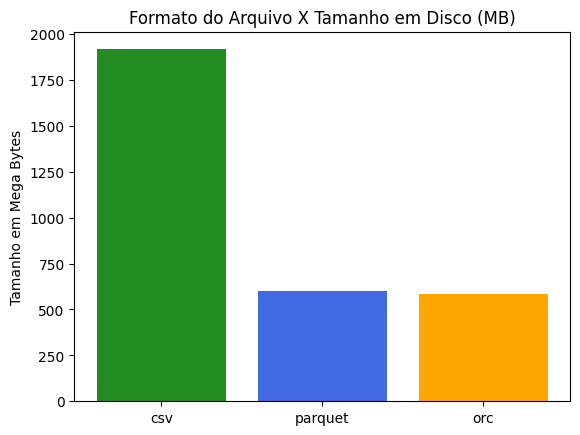

In [ ]:
# Grafico 1
plt.bar(["csv", "parquet", "orc"], [tamanho_csv, tamanho_parquet, tamanho_orc], color = ['forestgreen', 'royalblue', 'orange'])
plt.ylabel("Tamanho em Mega Bytes")
plt.title("Formato do Arquivo X Tamanho em Disco (MB)")
plt.show()

[]

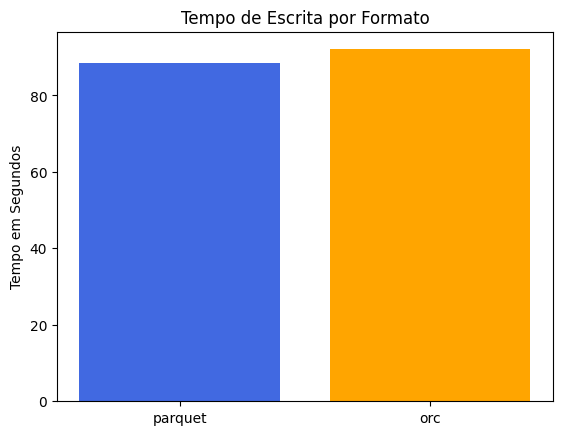

In [ ]:
# Grafico 2
plt.bar(["parquet", "orc"], tempos_escrita, color = ["royalblue", "orange"])
plt.title("Tempo de Escrita por Formato")
plt.ylabel("Tempo em Segundos")
plt.plot()

[]

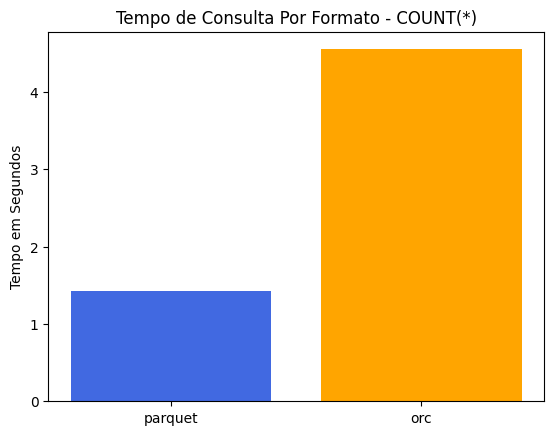

In [ ]:
# Grafico 3
plt.bar(["parquet", "orc"], tempos_consulta, color = ["royalblue", "orange"])
plt.title("Tempo de Consulta Por Formato - COUNT(*)")
plt.ylabel("Tempo em Segundos")
plt.plot()

[]

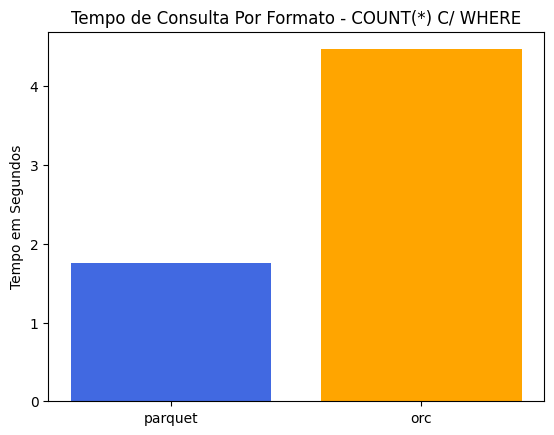

In [ ]:
# Grafico 4
plt.bar(["parquet", "orc"], tempos_consul_where, color = ["royalblue", "orange"])
plt.title("Tempo de Consulta Por Formato - COUNT(*) C/ WHERE")
plt.ylabel("Tempo em Segundos")
plt.plot()